# Parallel Volume Rendering using Dask


The dataset is stored in an HDF5 file containing a 3D density cube.
The rendering process rotates the volume at different viewing angles and projects the density values onto a 2D image.
To visualize the internal structures of the data, a transfer function is used to map density values to color (RGB) and opacity (alpha). Alpha compositing is then applied slice-by-slice to accumulate the final image. 
In this implementation, Dask is used to parallelize the rendering process by distributing the computation of different viewing angles across multiple workers. Each worker independently computes one rendered image, which significantly reduces the total execution time compared to sequential execution. Additionally, the Matplotlib backend is set to 'Agg' so that images can be generated safely inside parallel worker processes without requiring a GUI.

In [2]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import h5py as h5
from scipy.interpolate import interpn
import dask
from dask.distributed import Client

def transferFunction(x):
    r = (
        1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.1 * np.exp(-((x + 3.0) ** 2) / 0.5)
    )
    g = (
        1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
        + 1.0 * np.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.1 * np.exp(-((x + 3.0) ** 2) / 0.5)
    )
    b = (
        0.1 * np.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
        + 1.0 * np.exp(-((x + 3.0) ** 2) / 0.5)
    )
    a = (
        1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.2 * np.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.05 * np.exp(-((x + 3.0) ** 2) / 0.5)
    )
    return r, g, b, a

def render_angle(i, datacube, points, Nangles):
    import h5py
    import dask.array as da
    with h5py.File(hdf5_path, "r") as f:
        datacube = da.from_array(f["density"], chunks="auto").compute()
        Nx, Ny, Nz = datacube.shape
        x = np.linspace(-Nx / 2, Nx / 2, Nx)
        y = np.linspace(-Ny / 2, Ny / 2, Ny)
        z = np.linspace(-Nz / 2, Nz / 2, Nz)
        points = (x, y, z)
        angle = np.pi / 2 * i / Nangles
        N = 180
        c = np.linspace(-N / 2, N / 2, N)
        qx, qy, qz = np.meshgrid(c, c, c)
        qxR = qx
        qyR = qy * np.cos(angle) - qz * np.sin(angle)
        qzR = qy * np.sin(angle) + qz * np.cos(angle)
        qi = np.array([qxR.ravel(), qyR.ravel(), qzR.ravel()]).T
        camera_grid = interpn(points, datacube, qi, method="linear").reshape((N, N, N))
        image = np.zeros((camera_grid.shape[1], camera_grid.shape[2], 3))
        for dataslice in camera_grid:
            r, g, b, a = transferFunction(np.log(dataslice))
            image[:, :, 0] = a * r + (1 - a) * image[:, :, 0]
            image[:, :, 1] = a * g + (1 - a) * image[:, :, 1]
            image[:, :, 2] = a * b + (1 - a) * image[:, :, 2]
        image = np.clip(image, 0.0, 1.0)
        plt.figure(figsize=(4, 4), dpi=80)
        plt.imshow(image)
        plt.axis("off")
        plt.savefig(f"volumerender{i}.png", dpi=240, bbox_inches="tight", pad_inches=0)
        plt.close()
    return f"volumerender{i}.png"

In this implementation, Dask parallelizes the volume rendering by distributing the computation of different viewing angles across multiple workers. Each call to render_angle() is converted into a delayed task using dask.delayed(). When dask.compute() is executed, Dask schedules these tasks and executes them concurrently. Since each rendering task is independent, they can run simultaneously on different CPU cores. In this case, the total number of tasks equals the number of viewing angles (10), allowing efficient task-level parallelism.

In [5]:
!python /Users/mridulachandrika/Documents/Schoolwork/HPC-Intro/FinalProject/Source/volumerender_dask.py

/Users/mridulachandrika/Documents/Schoolwork/HPC-Intro/.venv/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 61393 instead
  warnings.warn(
Dask dashboard: http://127.0.0.1:61393/status
Rendered images: ('volumerender0.png', 'volumerender1.png', 'volumerender2.png', 'volumerender3.png', 'volumerender4.png', 'volumerender5.png', 'volumerender6.png', 'volumerender7.png', 'volumerender8.png', 'volumerender9.png')


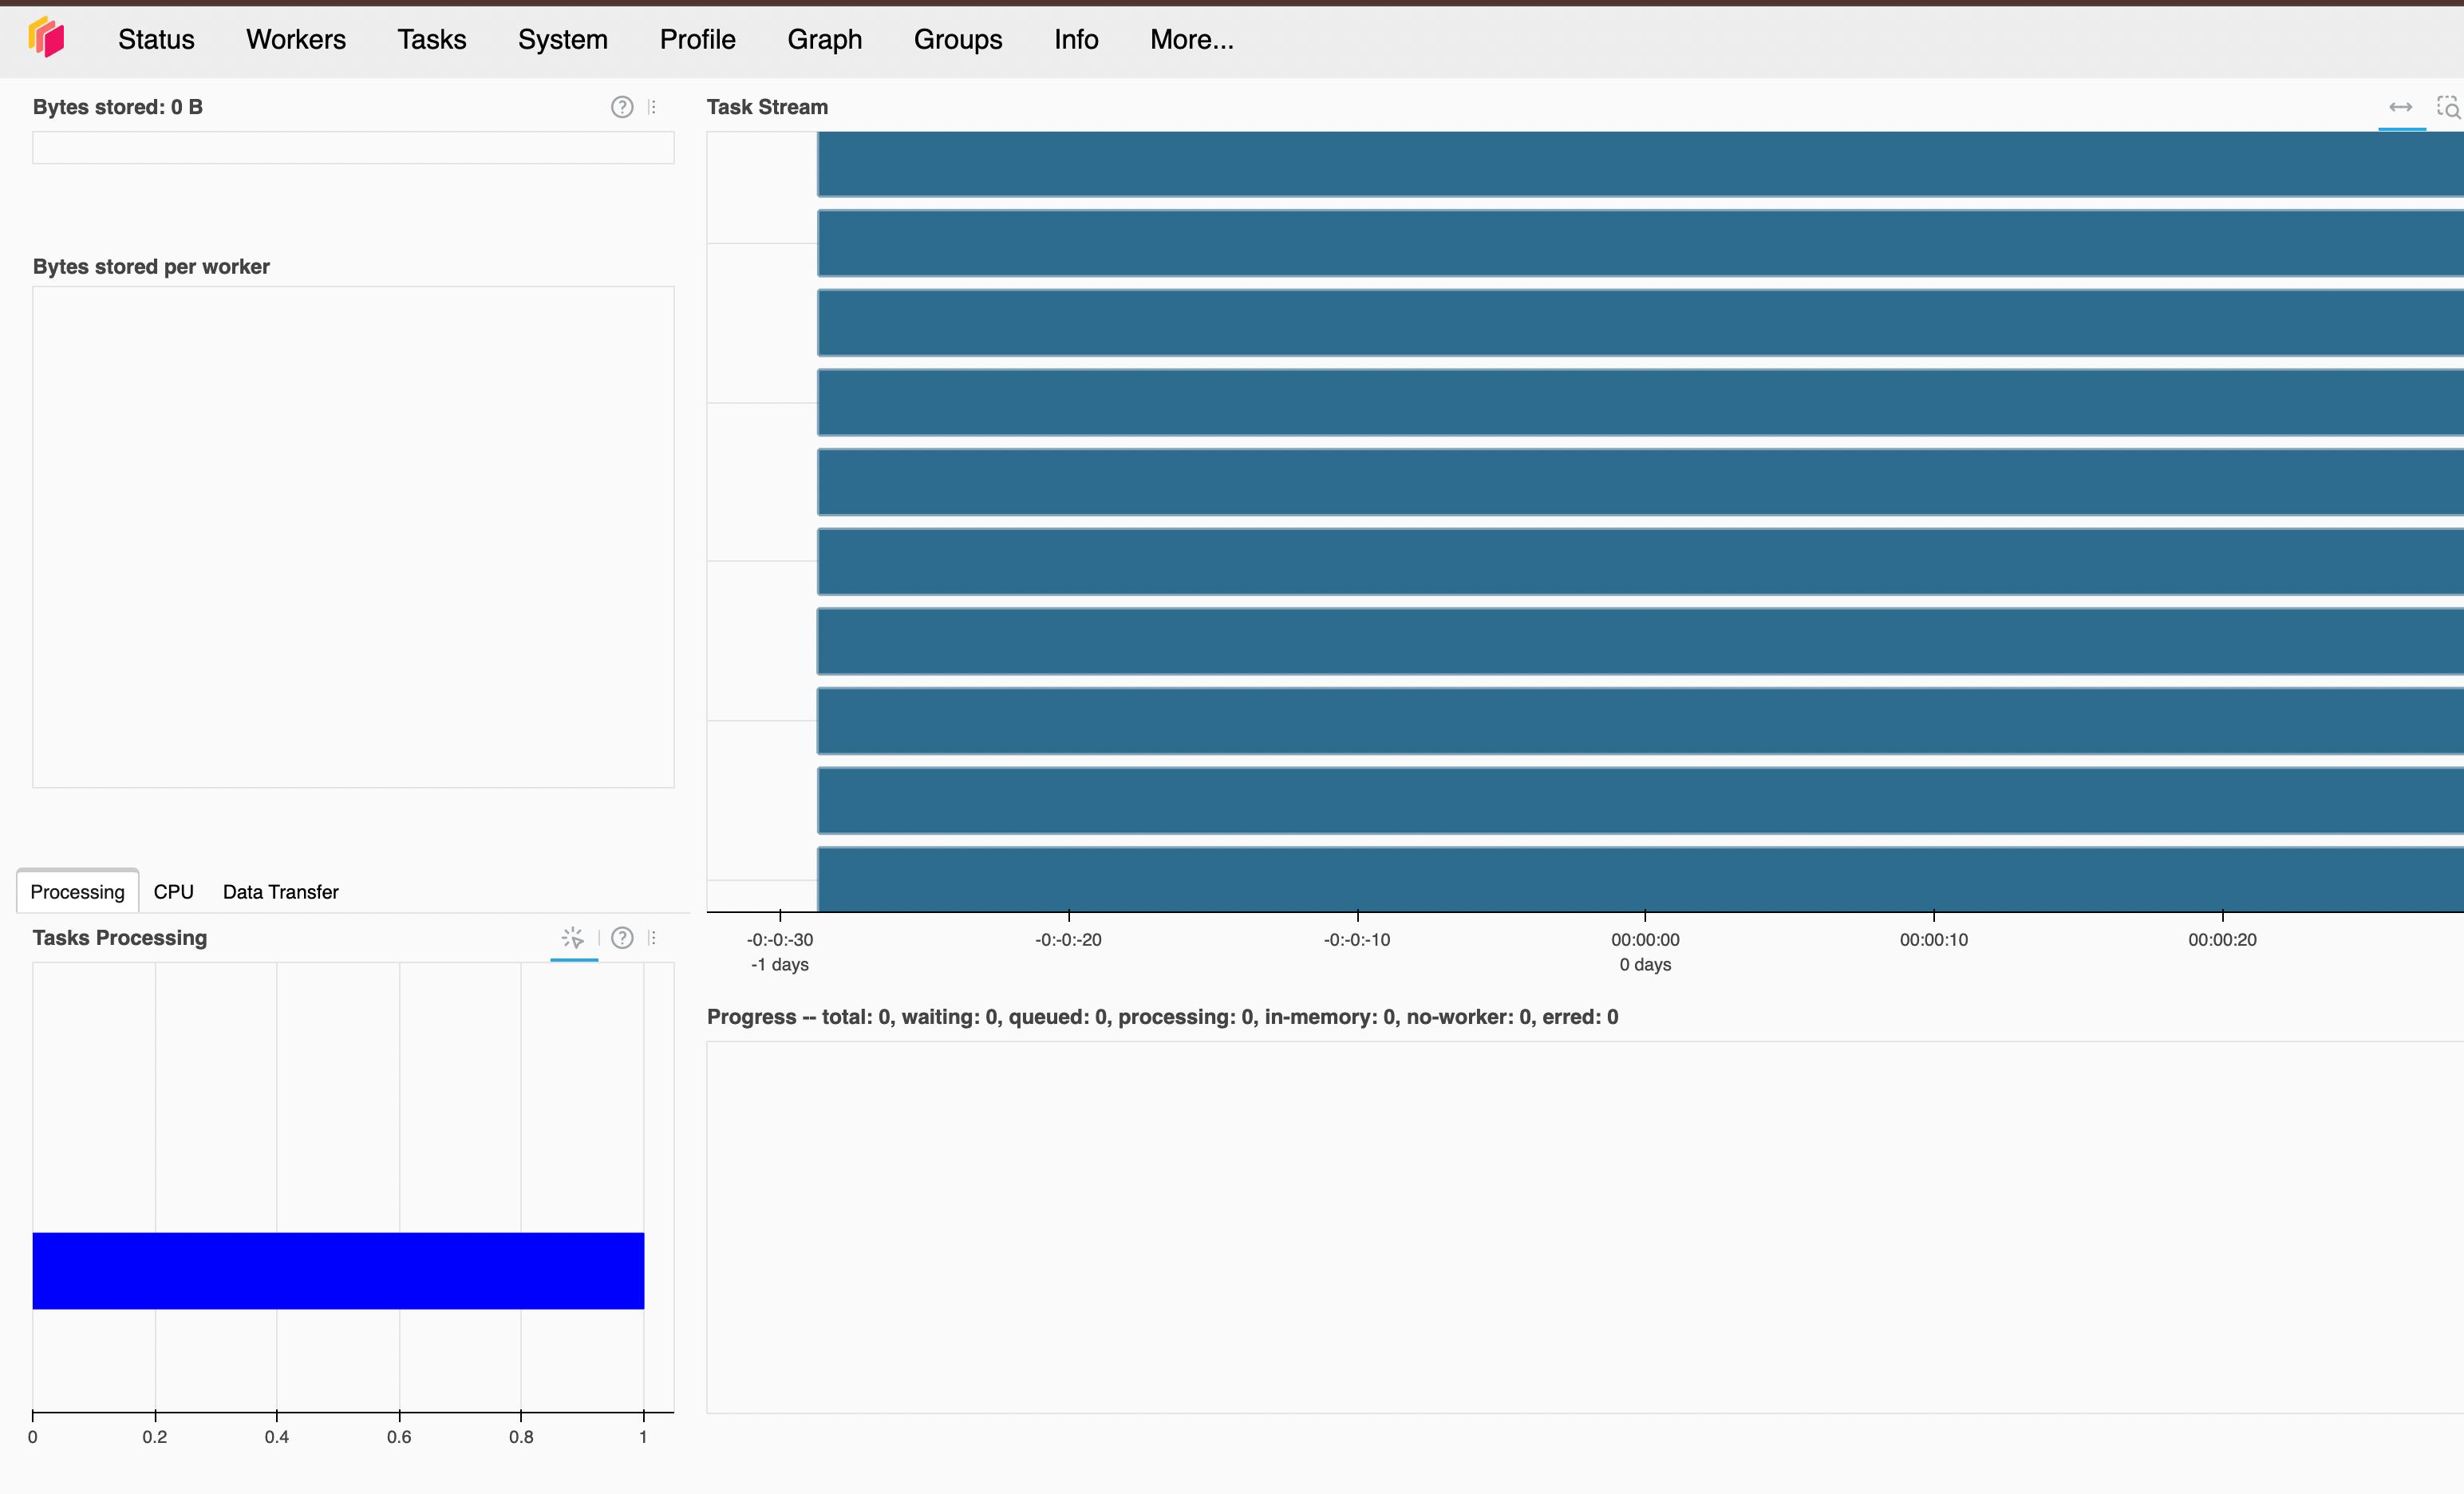

The Dask dashboard provides real-time visualization of task execution during parallel processing. Each rendering task corresponding to a different viewing angle is scheduled independently and executed across available workers. The task stream confirms that multiple tasks run concurrently, demonstrating effective parallelization of the volume rendering process. This improves computational efficiency by utilizing multiple CPU cores simultaneously.